#Comparative Study of Activation Function
by Rohith John 24BAD100

##Part A: VISUALIZATION OF ACTIVATION FUNCTIONS

In [21]:
# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt
print("Rohith John 24BAD100")
# 2. Define Activation Functions and their Derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_func(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

Rohith John 24BAD100


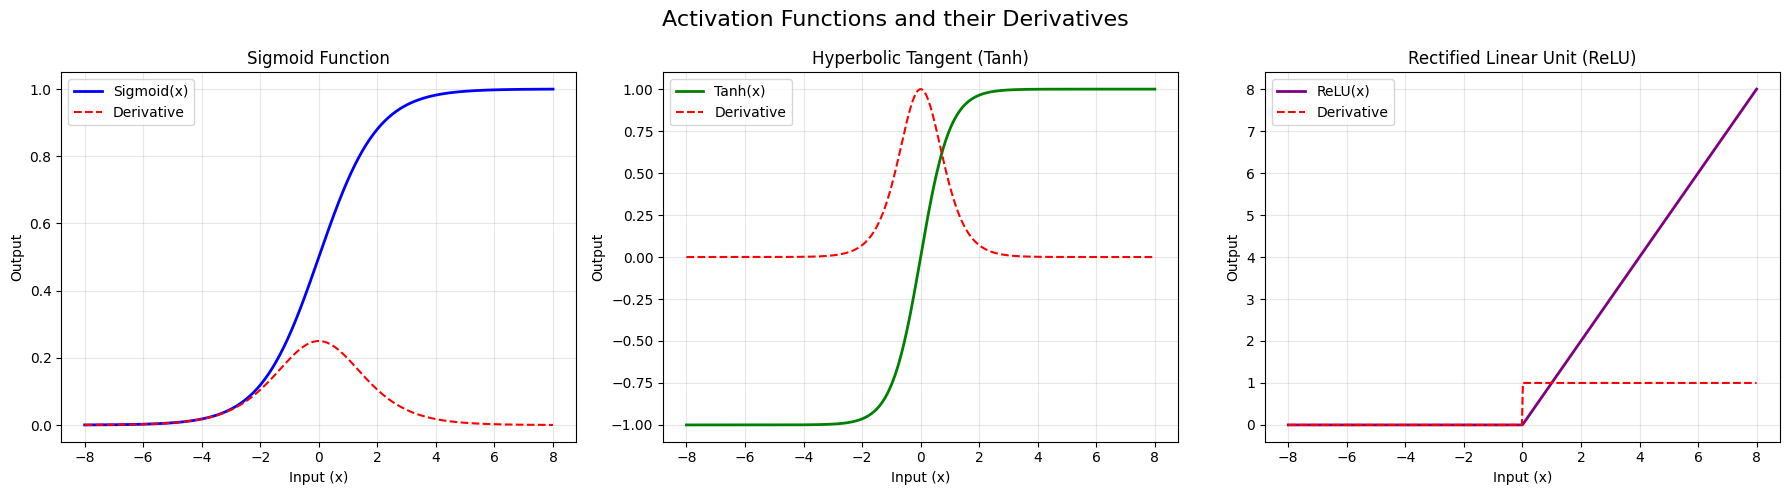

In [22]:
# 3. Generate input data
x = np.linspace(-8, 8, 500)

# 4. Create subplots for visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Activation Functions and their Derivatives', fontsize=16)

# Plot Sigmoid
axes[0].plot(x, sigmoid(x), label='Sigmoid(x)', color='blue', linewidth=2)
axes[0].plot(x, sigmoid_derivative(x), label="Derivative", color='red', linestyle='--')
axes[0].set_title('Sigmoid Function')
axes[0].set_xlabel('Input (x)')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot Tanh
axes[1].plot(x, tanh_func(x), label='Tanh(x)', color='green', linewidth=2)
axes[1].plot(x, tanh_derivative(x), label="Derivative", color='red', linestyle='--')
axes[1].set_title('Hyperbolic Tangent (Tanh)')
axes[1].set_xlabel('Input (x)')
axes[1].set_ylabel('Output')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot ReLU
axes[2].plot(x, relu(x), label='ReLU(x)', color='purple', linewidth=2)
axes[2].plot(x, relu_derivative(x), label="Derivative", color='red', linestyle='--')
axes[2].set_title('Rectified Linear Unit (ReLU)')
axes[2].set_xlabel('Input (x)')
axes[2].set_ylabel('Output')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [23]:
# 5. Output the required comparative analysis
print("ACTIVATION FUNCTION COMPARISON SUMMARY")
print("-" * 105)
print(f"{'Feature':<22} | {'Sigmoid':<25} | {'Tanh':<25} | {'ReLU':<25}")
print("-" * 105)
print(f"{'Output Range':<22} | {'(0, 1)':<25} | {'(-1, 1)':<25} | {'[0, ∞)':<25}")
print(f"{'Saturation Regions':<22} | {'x << 0 and x >> 0':<25} | {'x << 0 and x >> 0':<25} | {'x <= 0 (Dying ReLU risk)':<25}")
print(f"{'Gradient Behavior':<22} | {'High risk of vanishing':<25} | {'Moderate risk of vanishing':<25} | {'Constant 1 for x > 0':<25}")
print(f"{'Computational Cost':<22} | {'High (Exponential)':<25} | {'High (Exponential)':<25} | {'Low (Max operation)':<25}")
print(f"{'Typical Applications':<22} | {'Binary classification':<25} | {'Hidden layers (legacy)':<25} | {'Modern Deep Neural Networks':<25}")
print("-" * 105)

ACTIVATION FUNCTION COMPARISON SUMMARY
---------------------------------------------------------------------------------------------------------
Feature                | Sigmoid                   | Tanh                      | ReLU                     
---------------------------------------------------------------------------------------------------------
Output Range           | (0, 1)                    | (-1, 1)                   | [0, ∞)                   
Saturation Regions     | x << 0 and x >> 0         | x << 0 and x >> 0         | x <= 0 (Dying ReLU risk) 
Gradient Behavior      | High risk of vanishing    | Moderate risk of vanishing | Constant 1 for x > 0     
Computational Cost     | High (Exponential)        | High (Exponential)        | Low (Max operation)      
Typical Applications   | Binary classification     | Hidden layers (legacy)    | Modern Deep Neural Networks
--------------------------------------------------------------------------------------------------------

##PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In [24]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
print("Rohith John M")
print("24BAD100\n")

Rohith John M
24BAD100



In [25]:
# 2. Load and prepare dataset
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
activation_functions = ['sigmoid', 'tanh', 'relu']
results = {}
histories = {}
# Early stopping to calculate convergence epochs (stops if val_loss doesn't improve for 15 epochs)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [27]:
# 4. Train identical architectures with different activation functions
for func in activation_functions:
    print(f"Training ANN with {func.upper()} activation function...")

    # Build identical architecture
    model = Sequential([
        Dense(32, activation=func, input_shape=(X_train_scaled.shape[1],)),
        Dense(16, activation=func),
        Dense(1, activation='sigmoid') # Output layer remains sigmoid for binary classification
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=150,
        batch_size=16,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    # Store history for plotting
    histories[func] = history

    # Evaluate model
    train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    convergence_epoch = len(history.epoch)

    # Record metrics
    results[func] = {
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Train Loss': train_loss,
        'Val Loss': val_loss,
        'Epochs to Converge': convergence_epoch
    }

Training ANN with SIGMOID activation function...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN with TANH activation function...
Training ANN with RELU activation function...


In [28]:
# 5. Output comparison table
print("\n" + "="*85)
print(f"{'Activation':<15} | {'Train Acc':<12} | {'Val Acc':<12} | {'Train Loss':<12} | {'Val Loss':<12} | {'Epochs'}")
print("="*85)
for func, metrics in results.items():
    print(f"{func.upper():<15} | {metrics['Train Acc']:.4f}      | {metrics['Val Acc']:.4f}      | {metrics['Train Loss']:.4f}      | {metrics['Val Loss']:.4f}      | {metrics['Epochs to Converge']}")
print("="*85 + "\n")


Activation      | Train Acc    | Val Acc      | Train Loss   | Val Loss     | Epochs
SIGMOID         | 0.9824      | 0.9737      | 0.0505      | 0.0665      | 80
TANH            | 0.9846      | 0.9649      | 0.0500      | 0.0653      | 30
RELU            | 0.8198      | 0.8070      | 0.4880      | 0.4802      | 15



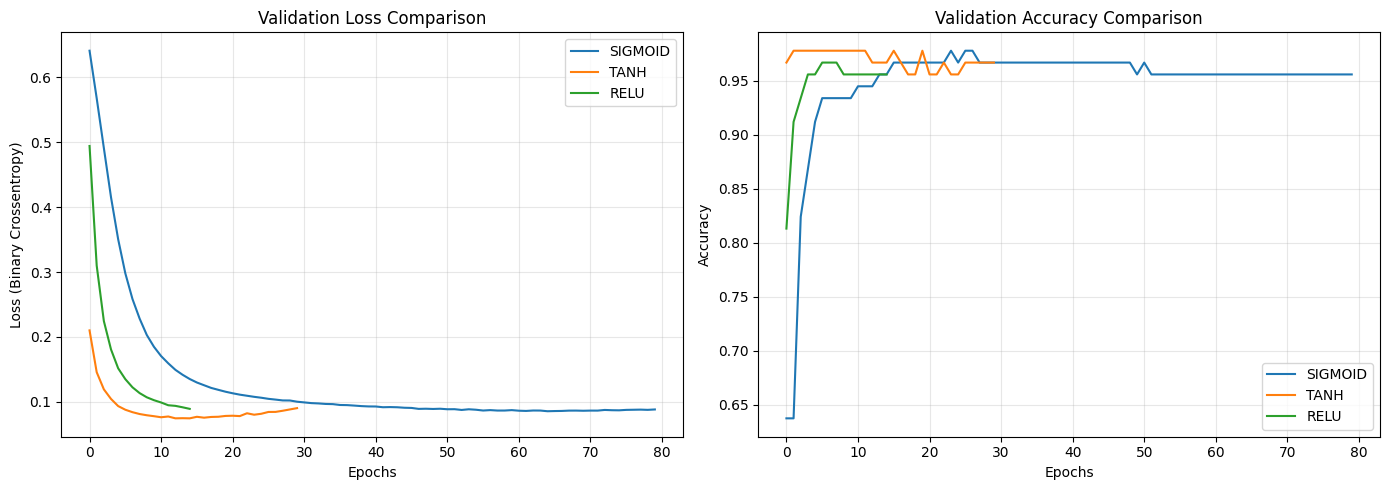

In [29]:
# 6. Plotting the performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Validation Loss
for func in activation_functions:
    axes[0].plot(histories[func].history['val_loss'], label=func.upper())
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Validation Accuracy
for func in activation_functions:
    axes[1].plot(histories[func].history['val_accuracy'], label=func.upper())
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##PART C: COMPARISON OF OPTIMIZATION ALGORITHMS 24BAD100 Rohith John

In [30]:
optimizers_dict = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

results_opt = {}
histories_opt = {}

In [31]:
# 2. Function to create a fresh, identical base model for each optimizer
def build_base_model():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid') # Output layer remains sigmoid for binary classification
    ])
    return model

In [32]:
# 3. Train and evaluate for each optimizer
epochs_c = 50 # Fixed epochs to observe convergence speed

for opt_name, opt in optimizers_dict.items():
    print(f"Training ANN with {opt_name} optimizer...")

    # Initialize a new model to ensure we don't start with pre-trained weights
    model = build_base_model()
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs_c,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    # Store history for plotting
    histories_opt[opt_name] = history

    # Evaluate model on final metrics
    train_loss, train_acc = model.evaluate(X_train_scaled, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

    # Record metrics
    results_opt[opt_name] = {
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Train Loss': train_loss,
        'Val Loss': val_loss
    }

Training ANN with SGD optimizer...
Training ANN with Momentum optimizer...
Training ANN with RMSProp optimizer...
Training ANN with Adam optimizer...



Optimizer    | Train Acc    | Val Acc      | Train Loss   | Val Loss    
SGD          | 0.9824       | 0.9737       | 0.0722       | 0.0717
Momentum     | 0.9912       | 0.9737       | 0.0278       | 0.1064
RMSProp      | 0.9912       | 0.9825       | 0.0251       | 0.1231
Adam         | 0.9912       | 0.9649       | 0.0228       | 0.1046



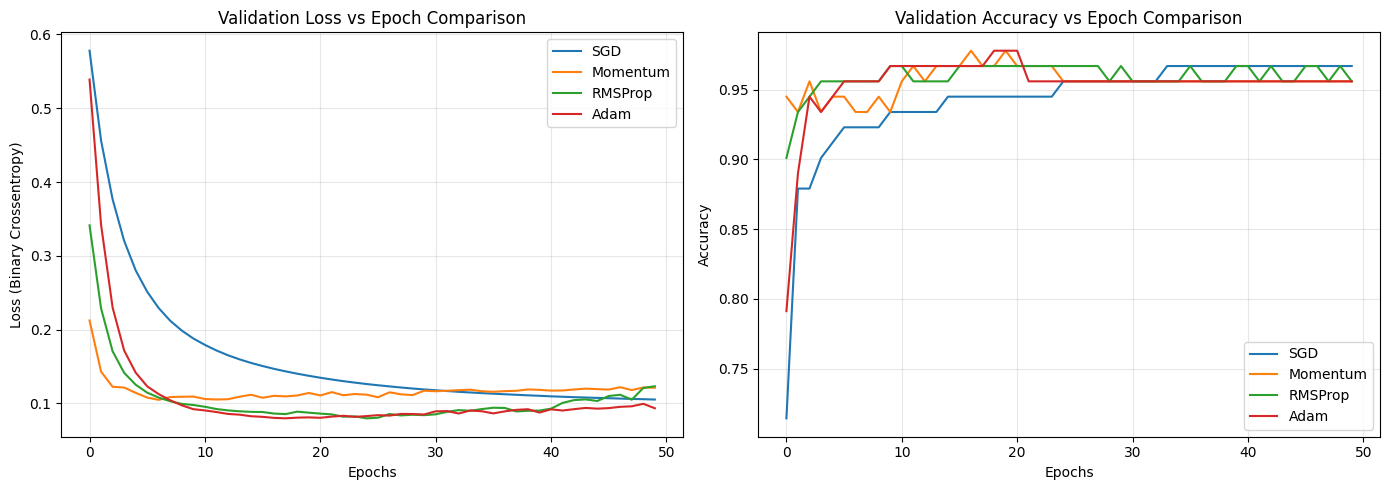

In [33]:
# 4. Output comparison table
print("\n" + "="*80)
print(f"{'Optimizer':<12} | {'Train Acc':<12} | {'Val Acc':<12} | {'Train Loss':<12} | {'Val Loss':<12}")
print("="*80)
for opt_name, metrics in results_opt.items():
    print(f"{opt_name:<12} | {metrics['Train Acc']:.4f}       | {metrics['Val Acc']:.4f}       | {metrics['Train Loss']:.4f}       | {metrics['Val Loss']:.4f}")
print("="*80 + "\n")

# 5. Plotting Loss and Accuracy vs Epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Validation Loss
for opt_name in optimizers_dict.keys():
    axes[0].plot(histories_opt[opt_name].history['val_loss'], label=opt_name)
axes[0].set_title('Validation Loss vs Epoch Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Validation Accuracy
for opt_name in optimizers_dict.keys():
    axes[1].plot(histories_opt[opt_name].history['val_accuracy'], label=opt_name)
axes[1].set_title('Validation Accuracy vs Epoch Comparison')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()